### Environment Setup
This cell installs the required Python libraries and downloads the spaCy language model used for NLP tasks.

In [1]:
!pip install pandas matplotlib seaborn spacy tqdm -q
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 70.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


### Libraries Import
This section imports all necessary libraries for data analysis, visualization, and natural language processing.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import spacy
import re
from collections import Counter
from tqdm import tqdm
from google.colab import drive

tqdm.pandas()

### Data Loading
This cell mounts Google Drive, loads the dataset, and prepares the dataframe for analysis.

In [3]:
drive.mount('/content/drive')

DRIVE_BASE   = '/content/drive/MyDrive/SMA_Loreti_Pegoraro'
DATA_SENT    = f'{DRIVE_BASE}/Data/reddit_comments_sentiment.csv'
VIZ_DIR      = f'{DRIVE_BASE}/Visualizations'

df = pd.read_csv(DATA_SENT)
df['created_utc'] = pd.to_datetime(df['created_utc'])
print(f'Comments loaded: {len(df)}')
print(f'Columns: {df.columns.tolist()}')
print(f'Period: {df["created_utc"].min()} -> {df["created_utc"].max()}')


Mounted at /content/drive
Commenti caricati: 24745
Colonne: ['post_id', 'comment_id', 'parent_id', 'author', 'body', 'text_clean', 'score', 'created_utc', 'subreddit', 'depth', 'vader_compound', 'vader_label', 'roberta_label', 'roberta_positive', 'roberta_neutral', 'roberta_negative']
Periodo: 2026-01-01 15:06:05 -> 2026-03-24 19:03:29


### Sentiment Over Time Analysis
This section analyzes how sentiment evolves over time by aggregating weekly VADER scores and visualizing trends.


-- Sentiment Over Time --
Weekly sentiment:
      week  avg_vader  n_comments
2025-12-29   0.153957          69
2026-01-05   0.173487         572
2026-01-12   0.322583         355
2026-01-19   0.255475         281
2026-01-26   0.239885         913
2026-02-02   0.229469        2740
2026-02-09   0.210948        5180
2026-02-16   0.238485        8166
2026-02-23   0.257026        4194
2026-03-02   0.199481        1251
2026-03-09   0.247989        1005
2026-03-16   0.229444          16
2026-03-23   0.438333           3


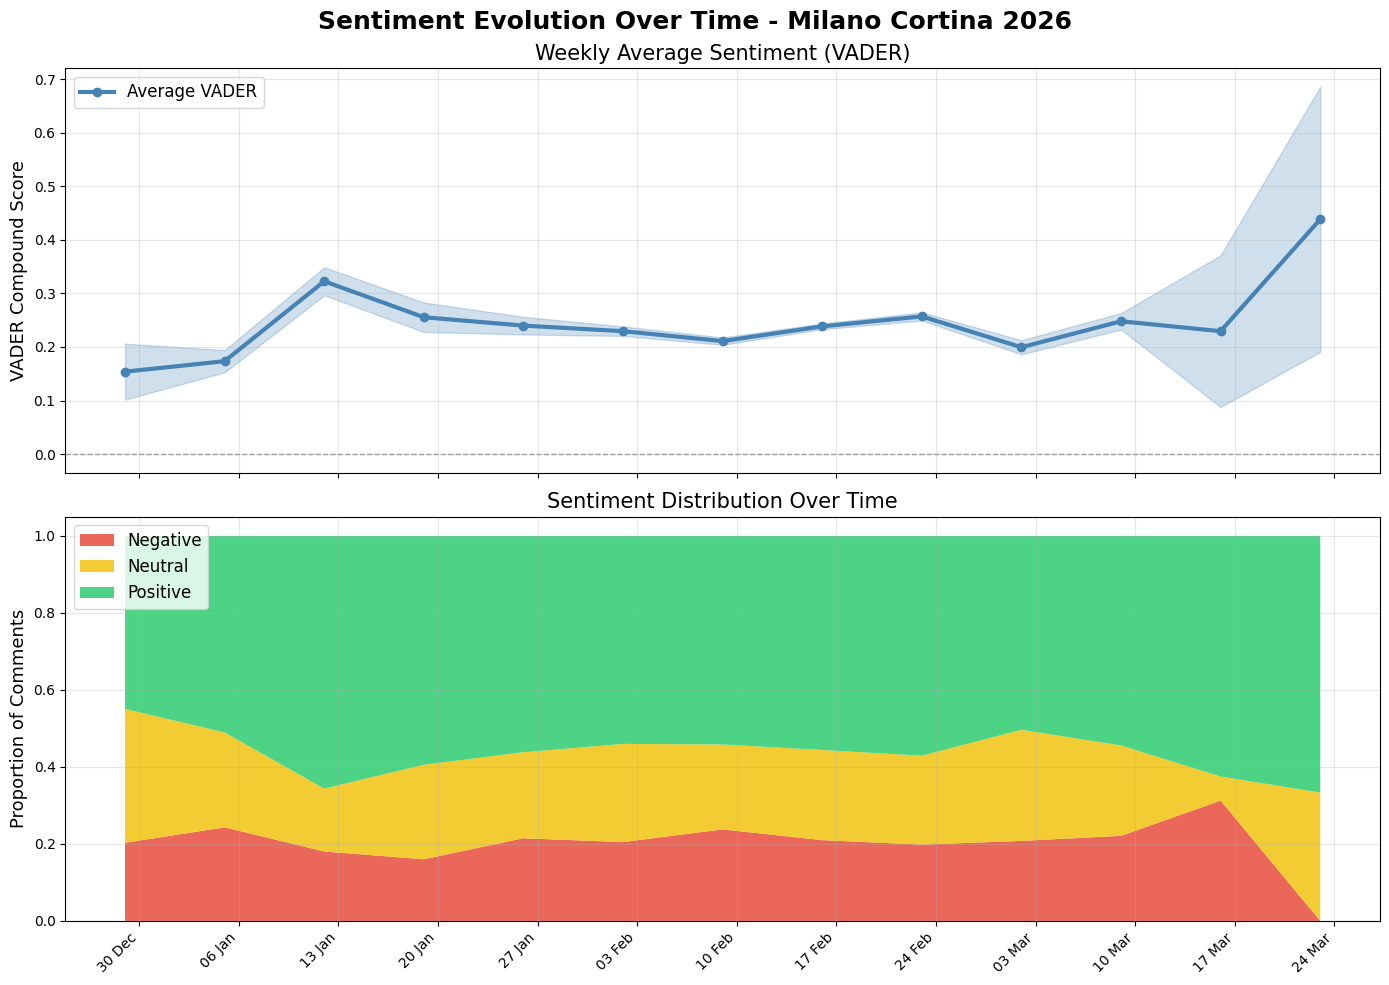

Saved: sentiment_over_time.png


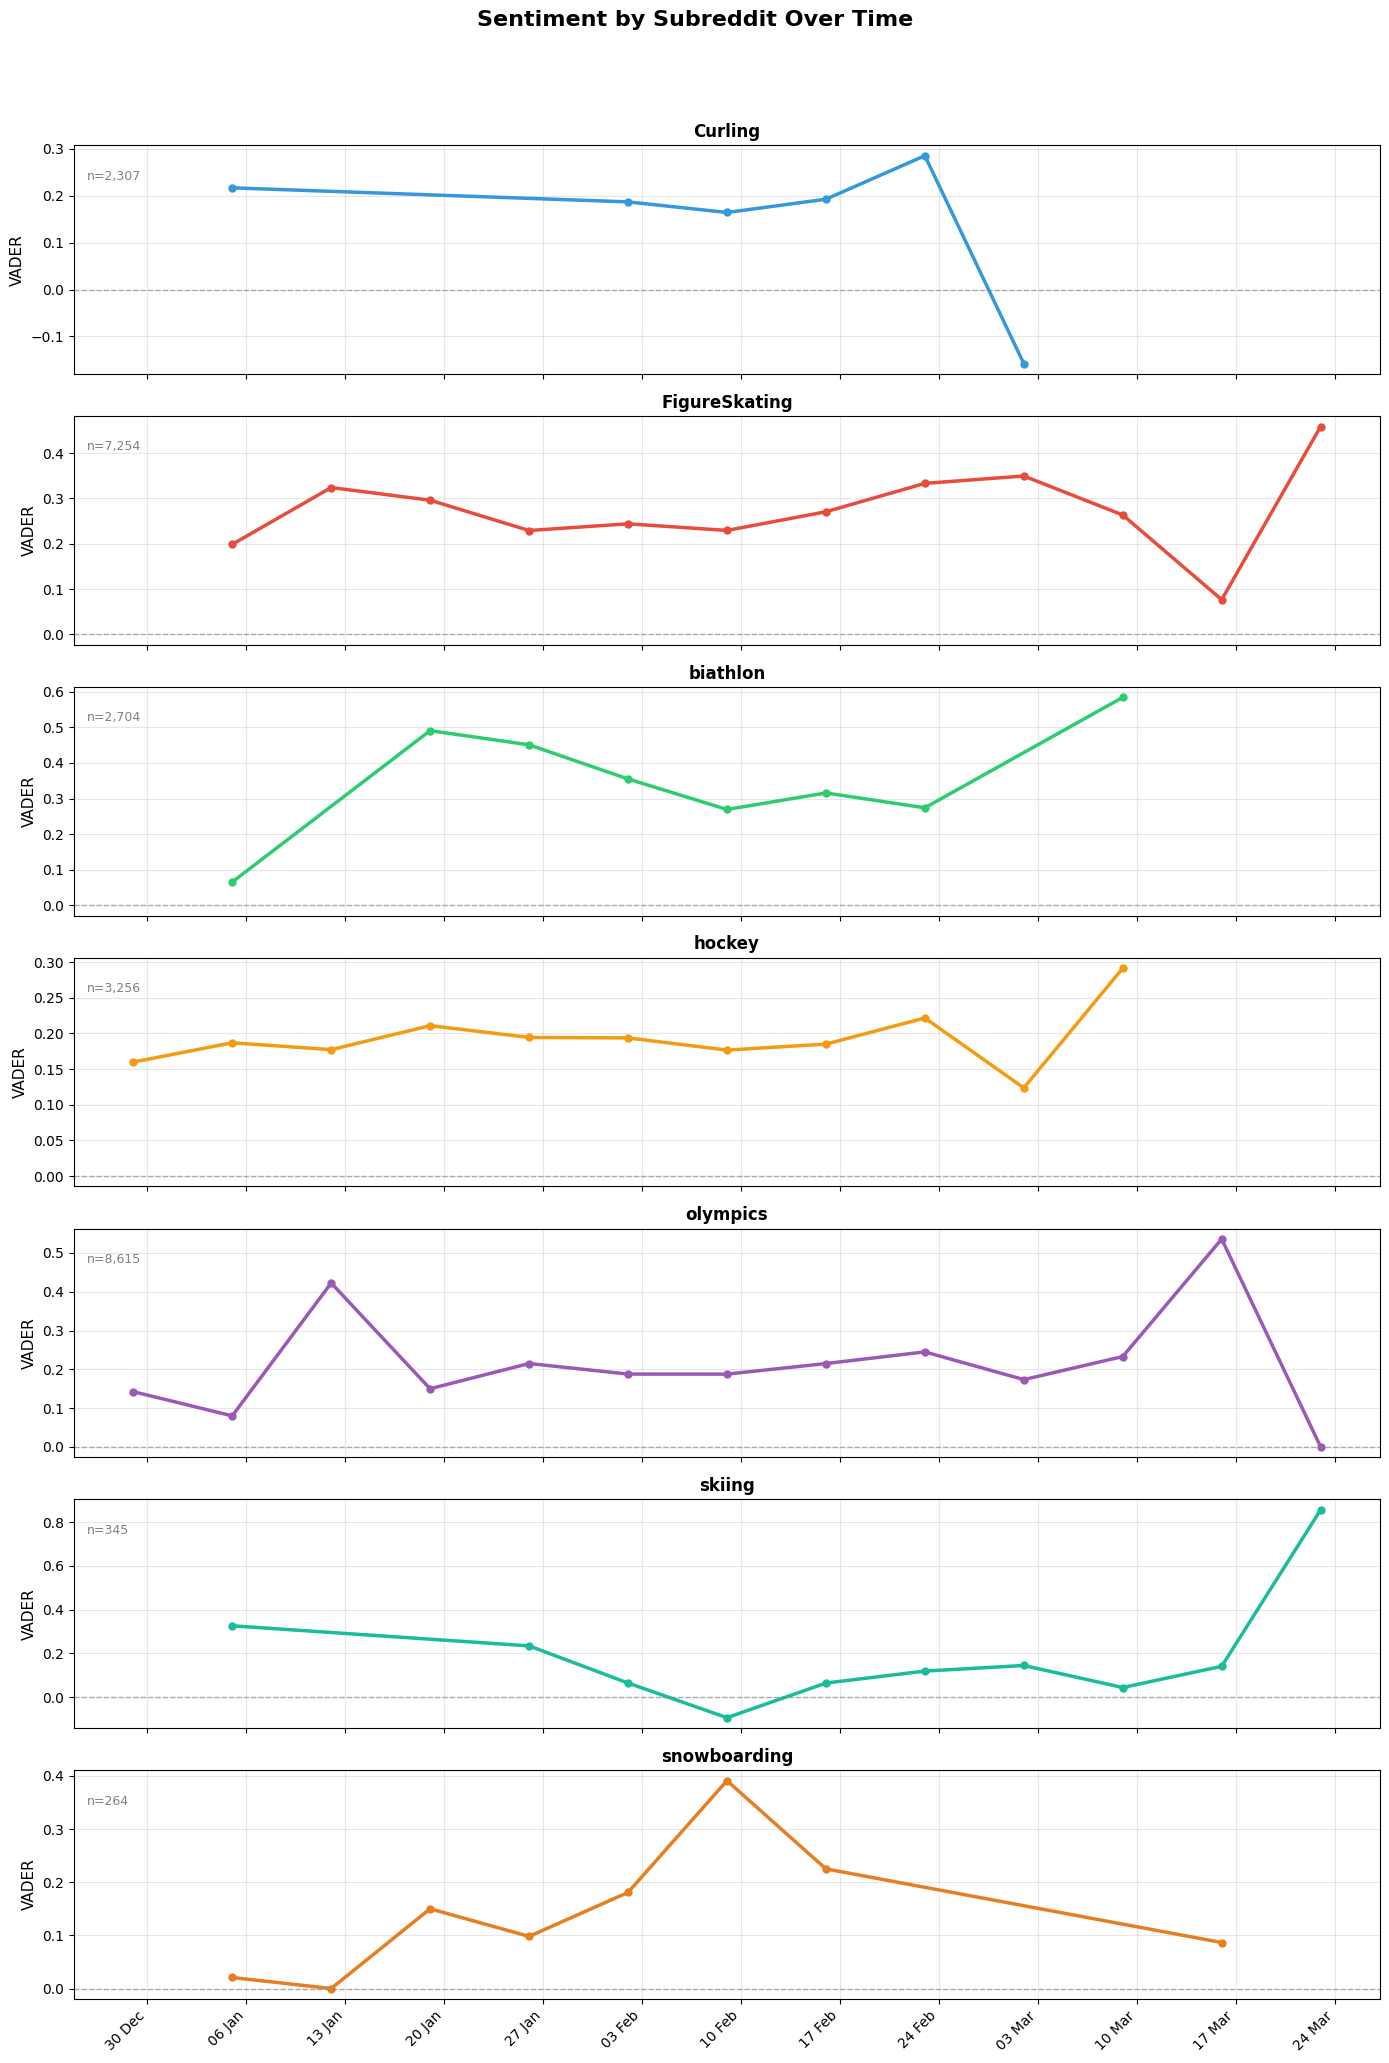

Saved: sentiment_by_subreddit_over_time.png


In [9]:
# ============================================================
#  SECTION A - SENTIMENT OVER TIME
# ============================================================
print('\n-- Sentiment Over Time --')

# Add week column
df['week'] = df['created_utc'].dt.to_period('W').dt.start_time

# Remove "r/" prefix from subreddit names
df['subreddit'] = df['subreddit'].str.replace(r'^r/', '', regex=True)

# Weekly sentiment aggregation (VADER compound)
weekly_sentiment = df.groupby('week').agg(
    avg_vader     = ('vader_compound', 'mean'),
    std_vader     = ('vader_compound', 'std'),
    n_comments    = ('vader_compound', 'count'),
    pct_positive  = ('vader_label', lambda x: (x == 'positive').mean()),
    pct_negative  = ('vader_label', lambda x: (x == 'negative').mean()),
    pct_neutral   = ('vader_label', lambda x: (x == 'neutral').mean()),
).reset_index()

print('Weekly sentiment:')
print(weekly_sentiment[['week', 'avg_vader', 'n_comments']].to_string(index=False))

# -- Plot 1: Average sentiment over time --------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Sentiment Evolution Over Time - Milano Cortina 2026',
             fontsize=18, fontweight='bold')

# Top panel: average VADER with confidence band
ax1 = axes[0]
ax1.plot(weekly_sentiment['week'], weekly_sentiment['avg_vader'],
         color='steelblue', linewidth=3, marker='o', markersize=6, label='Average VADER')

ax1.fill_between(
    weekly_sentiment['week'],
    weekly_sentiment['avg_vader'] - weekly_sentiment['std_vader'] / np.sqrt(weekly_sentiment['n_comments']),
    weekly_sentiment['avg_vader'] + weekly_sentiment['std_vader'] / np.sqrt(weekly_sentiment['n_comments']),
    alpha=0.25, color='steelblue'
)

ax1.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
ax1.set_ylabel('VADER Compound Score', fontsize=13)
ax1.set_title('Weekly Average Sentiment (VADER)', fontsize=15)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

# Bottom panel: sentiment distribution
ax2 = axes[1]
ax2.stackplot(
    weekly_sentiment['week'],
    weekly_sentiment['pct_negative'],
    weekly_sentiment['pct_neutral'],
    weekly_sentiment['pct_positive'],
    labels=['Negative', 'Neutral', 'Positive'],
    colors=['#e74c3c', '#f1c40f', '#2ecc71'],
    alpha=0.85
)

ax2.set_ylabel('Proportion of Comments', fontsize=13)
ax2.set_title('Sentiment Distribution Over Time', fontsize=15)
ax2.legend(loc='upper left', fontsize=12)

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax2.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig('/content/drive/MyDrive/SMA_Loreti_Pegoraro/Visualizations/sentiment_over_time.png',
            dpi=300, bbox_inches='tight')

plt.show()
print('Saved: sentiment_over_time.png')

# -- Plot 2: Sentiment by subreddit over time ------------
subreddits = df['subreddit'].unique()

fig, axes = plt.subplots(len(subreddits), 1,
                          figsize=(14, 3 * len(subreddits)), sharex=True)

fig.suptitle('Sentiment by Subreddit Over Time',
             fontsize=16, fontweight='bold')

colors_sub = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22']

for i, sub in enumerate(sorted(subreddits)):
    sub_df = df[df['subreddit'] == sub].copy()
    sub_weekly = sub_df.groupby('week')['vader_compound'].mean().reset_index()

    ax = axes[i]
    ax.plot(sub_weekly['week'], sub_weekly['vader_compound'],
            color=colors_sub[i % len(colors_sub)],
            linewidth=2.5, marker='o', markersize=5)

    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.6)

    ax.set_ylabel('VADER', fontsize=11)
    ax.set_title(f'{sub}', fontsize=12, fontweight='bold')

    ax.grid(True, alpha=0.3)

    n = len(sub_df)
    ax.text(0.01, 0.85, f'n={n:,}', transform=ax.transAxes,
            fontsize=9, color='gray')

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig('/content/drive/MyDrive/SMA_Loreti_Pegoraro/Visualizations/sentiment_by_subreddit_over_time.png',
            dpi=300, bbox_inches='tight')

plt.show()
print('Saved: sentiment_by_subreddit_over_time.png')

### Named Entity Recognition (NER)
This section extracts and analyzes named entities (e.g., people, places, organizations) mentioned in the comments.


-- Named Entity Recognition (NER) --
Running NER on sample of 8000 comments...


100%|██████████| 8000/8000 [01:17<00:00, 103.32it/s]


Extracted entities: 17551
Entity types: {'PERSON': 3217, 'GPE': 3105, 'ORG': 2614, 'CARDINAL': 2548, 'DATE': 2236, 'NORP': 1177, 'EVENT': 912, 'ORDINAL': 710, 'TIME': 262, 'FAC': 128, 'LOC': 127, 'PRODUCT': 123, 'PERCENT': 100, 'WORK_OF_ART': 94, 'QUANTITY': 90, 'MONEY': 56, 'LAW': 28, 'LANGUAGE': 24}

Top 10 People / Athletes:
text
alysa        97
kaori        63
ami          34
shun         31
alysa liu    28
ilia         28
yuma         26
worlds       25
max          24
sturla       22

Top 10 Countries / Cities:
text
canada     282
italy      156
usa        137
norway     136
russia     100
china       99
sweden      95
germany     71
france      63
japan       63

Top 10 Organizations:
text
nbc            66
nhl            61
ioc            43
pcs            42
paralympics    35
isu            33
team usa       27
cbc            27
slovakia       27
jbb            24

Top 10 Events:
text
olympics                   590
olympic                    113
the winter olympics         22


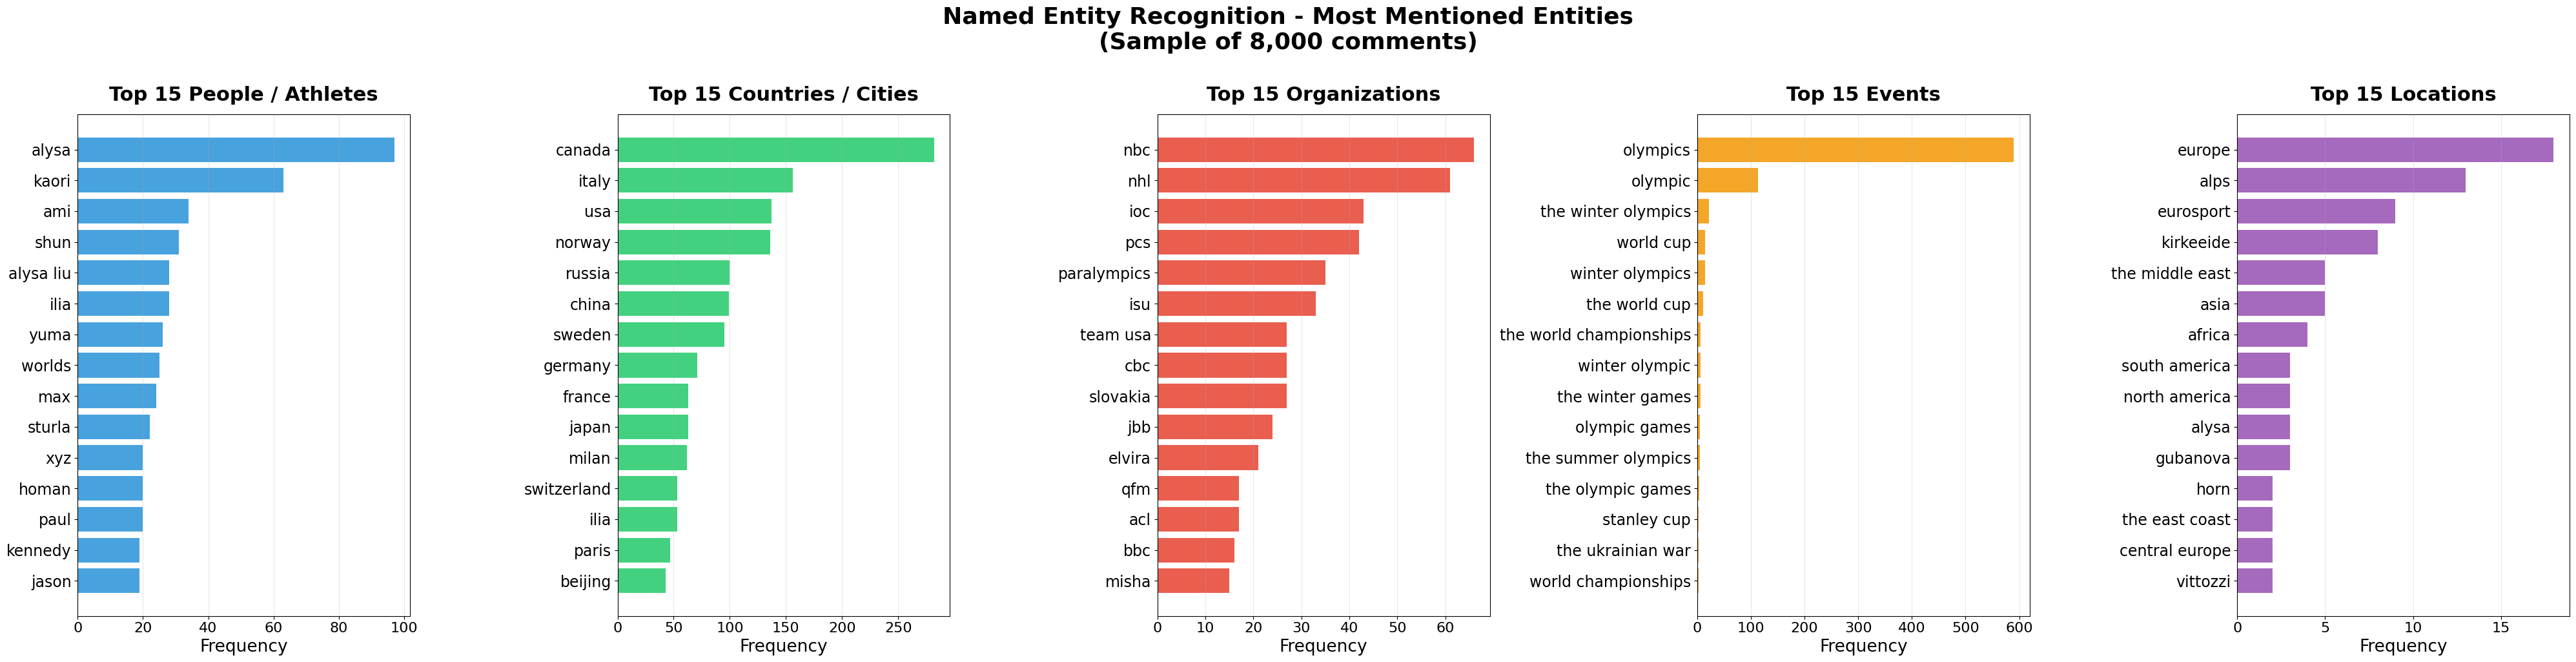

Saved: ner_top_entities.png


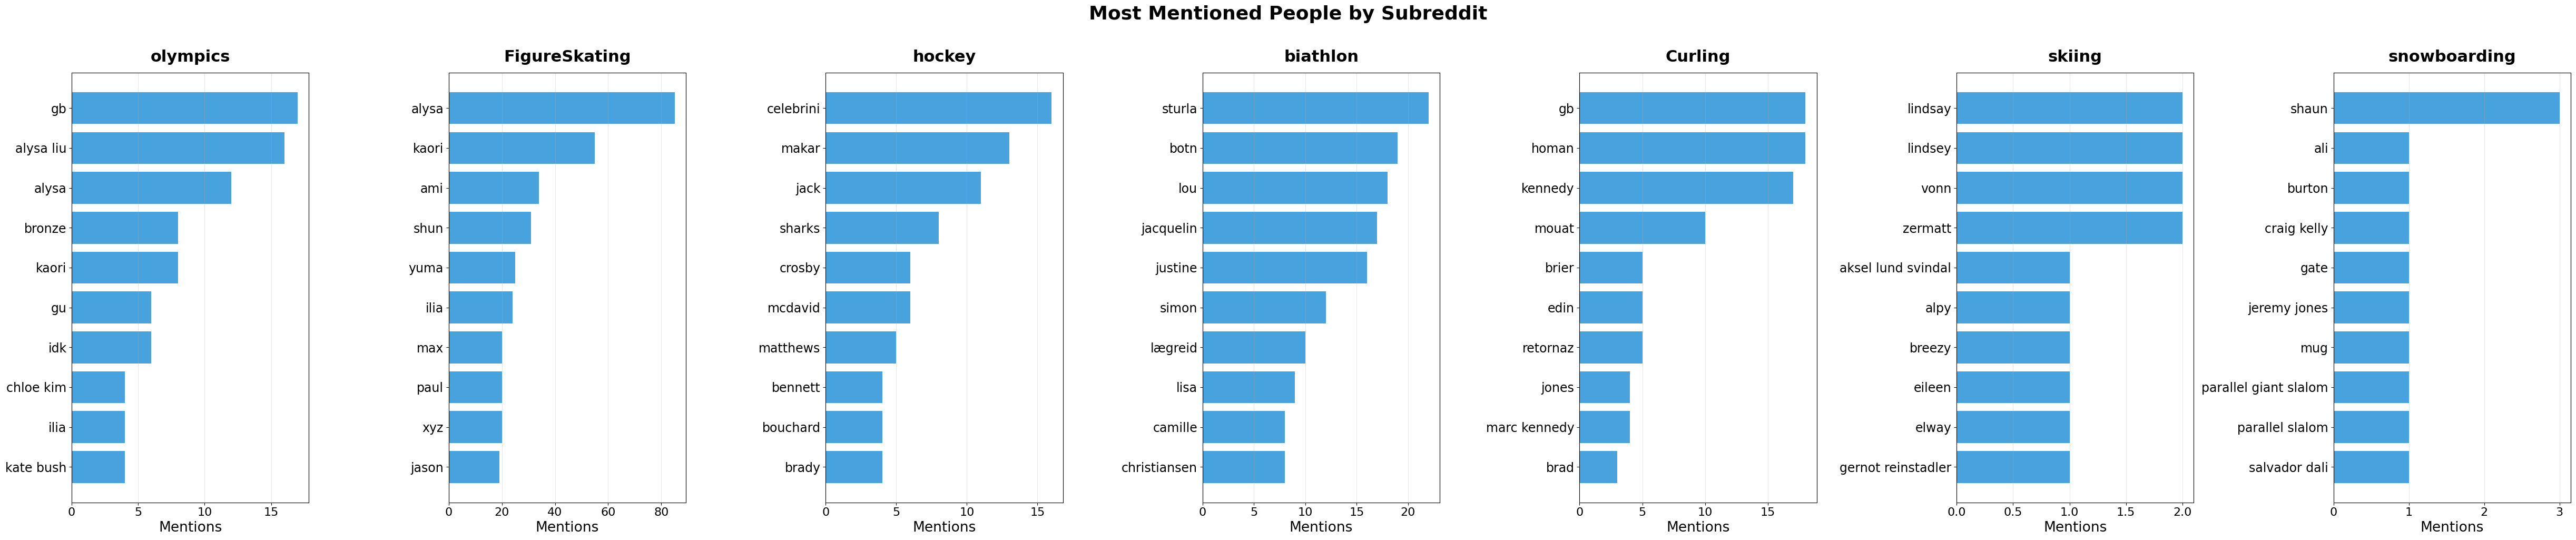

Saved: ner_people_by_subreddit.png


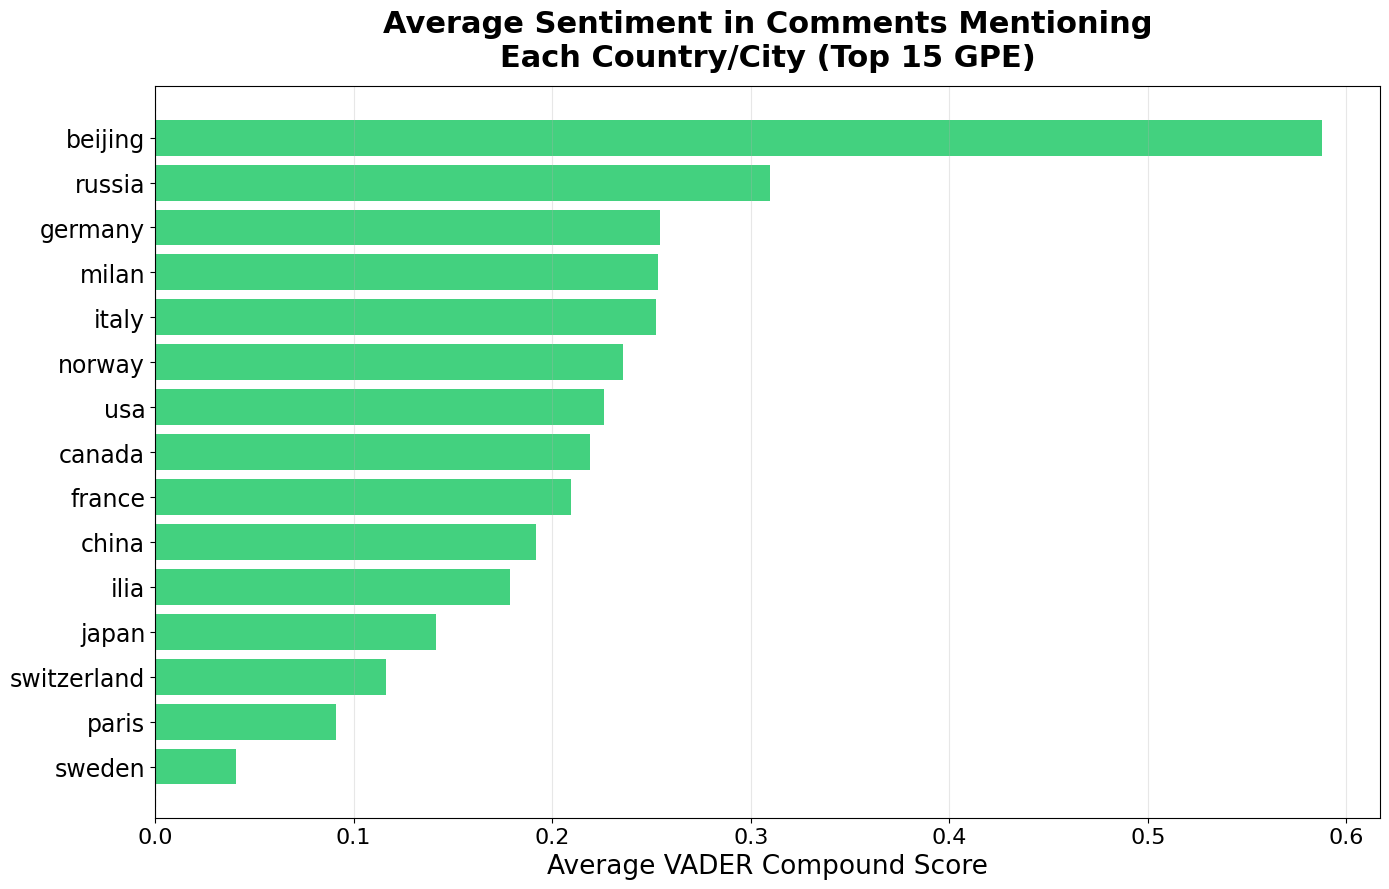

Saved: ner_sentiment_by_country.png


In [11]:
# ============================================================
#  SECTION B - NAMED ENTITY RECOGNITION (NER)
# ============================================================
print('\n-- Named Entity Recognition (NER) --')

nlp = spacy.load('en_core_web_sm')

def extract_entities(text):
    if not isinstance(text, str) or text.strip() == '':
        return []
    doc = nlp(text[:1000])
    return [(ent.text.strip(), ent.label_) for ent in doc.ents]

sample_size = min(8000, len(df))
df_sample = df.sample(n=sample_size, random_state=42).copy()

print(f'Running NER on sample of {sample_size} comments...')
df_sample['entities'] = df_sample['body'].progress_apply(extract_entities)

all_entities = []
for _, row in df_sample.iterrows():
    for ent_text, ent_label in row['entities']:
        all_entities.append({
            'text'     : ent_text,
            'label'    : ent_label,
            'subreddit': str(row['subreddit']).replace('r/', ''),
            'sentiment': row.get('vader_label', 'neutral'),
        })

entities_df = pd.DataFrame(all_entities)

print(f'Extracted entities: {len(entities_df)}')
print(f'Entity types: {entities_df["label"].value_counts().to_dict()}')

relevant_types = {
    'PERSON' : 'People / Athletes',
    'GPE'    : 'Countries / Cities',
    'ORG'    : 'Organizations',
    'EVENT'  : 'Events',
    'LOC'    : 'Locations',
}

top_entities = {}
for ent_type, label in relevant_types.items():
    subset = entities_df[entities_df['label'] == ent_type]
    if len(subset) == 0:
        continue

    counts = (
        subset['text']
        .str.lower()
        .str.strip()
        .value_counts()
    )

    counts = counts[counts.index.str.len() >= 3]
    top_entities[ent_type] = counts.head(20)

    print(f'\nTop 10 {label}:')
    print(counts.head(10).to_string())

# -- Plot 3: Top entities by type --------------------------
fig, axes = plt.subplots(1, len(top_entities), figsize=(8 * len(top_entities), 10))

if len(top_entities) == 1:
    axes = [axes]

ent_colors = {
    'PERSON': '#3498db',
    'GPE'   : '#2ecc71',
    'ORG'   : '#e74c3c',
    'EVENT' : '#f39c12',
    'LOC'   : '#9b59b6'
}

for ax, (ent_type, counts) in zip(axes, top_entities.items()):
    top15 = counts.head(15)

    ax.barh(top15.index[::-1], top15.values[::-1],
            color=ent_colors.get(ent_type, 'steelblue'), alpha=0.9)

    ax.set_title(f'Top 15 {relevant_types[ent_type]}',
                 fontsize=22, fontweight='bold', pad=15)

    ax.set_xlabel('Frequency', fontsize=19)
    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=17)
    ax.grid(True, axis='x', alpha=0.3)

fig.suptitle('Named Entity Recognition - Most Mentioned Entities\n(Sample of 8,000 comments)',
             fontsize=26, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/SMA_Loreti_Pegoraro/Visualizations/ner_top_entities.png',
            dpi=300, bbox_inches='tight')
plt.show()
print('Saved: ner_top_entities.png')

# -- Plot 4: Top PEOPLE by subreddit --------------------
if 'PERSON' in top_entities:

    person_sub = (
        entities_df[entities_df['label'] == 'PERSON']
        .assign(text=lambda x: x['text'].str.lower().str.strip())
        .groupby(['subreddit', 'text'])
        .size()
        .reset_index(name='count')
    )

    subreddits_sorted = df['subreddit'].str.replace(r'^r/', '', regex=True).value_counts().index.tolist()
    n_sub = len(subreddits_sorted)

    fig, axes = plt.subplots(1, n_sub, figsize=(7 * n_sub, 10))

    if n_sub == 1:
        axes = [axes]

    fig.suptitle('Most Mentioned People by Subreddit',
                 fontsize=26, fontweight='bold', y=1.02)

    for ax, sub in zip(axes, subreddits_sorted):
        sub_persons = person_sub[person_sub['subreddit'] == sub].nlargest(10, 'count')

        if len(sub_persons) == 0:
            ax.set_visible(False)
            continue

        ax.barh(sub_persons['text'][::-1],
                sub_persons['count'][::-1],
                color='#3498db', alpha=0.9)

        ax.set_title(f'{sub}', fontsize=22, fontweight='bold', pad=15)
        ax.set_xlabel('Mentions', fontsize=19)
        ax.tick_params(axis='x', labelsize=16)
        ax.tick_params(axis='y', labelsize=17)
        ax.grid(True, axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/SMA_Loreti_Pegoraro/Visualizations/ner_people_by_subreddit.png',
                dpi=300, bbox_inches='tight')
    plt.show()
    print('Saved: ner_people_by_subreddit.png')

# -- Plot 5: Average sentiment by country (GPE) ------------
if 'GPE' in top_entities:

    top_gpe = top_entities['GPE'].head(15).index.tolist()

    gpe_sentiment = (
        entities_df[
            (entities_df['label'] == 'GPE') &
            (entities_df['text'].str.lower().isin(top_gpe))
        ]
        .merge(
            df_sample[['body', 'vader_compound']],
            left_index=True, right_index=True,
            how='left'
        )
    )

    gpe_avg = (
        gpe_sentiment
        .groupby(entities_df['text'].str.lower())['vader_compound']
        .agg(['mean', 'count'])
        .query('count >= 10')
        .sort_values('mean')
    )

    if len(gpe_avg) > 0:

        fig, ax = plt.subplots(figsize=(14, 9))

        colors_gpe = ['#e74c3c' if v < 0 else '#2ecc71' for v in gpe_avg['mean']]

        ax.barh(gpe_avg.index, gpe_avg['mean'],
                color=colors_gpe, alpha=0.9)

        ax.axvline(0, color='gray', linestyle='--', linewidth=1.5)

        ax.set_xlabel('Average VADER Compound Score', fontsize=19)
        ax.set_title('Average Sentiment in Comments Mentioning\nEach Country/City (Top 15 GPE)',
                     fontsize=22, fontweight='bold', pad=15)
        ax.tick_params(axis='x', labelsize=16)
        ax.tick_params(axis='y', labelsize=17)
        ax.grid(True, axis='x', alpha=0.3)

        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/SMA_Loreti_Pegoraro/Visualizations/ner_sentiment_by_country.png',
                    dpi=300, bbox_inches='tight')
        plt.show()
        print('Saved: ner_sentiment_by_country.png')

NER DATA SAVING

In [6]:
# ============================================================
#  SALVATAGGIO DATI NER
# ============================================================
entities_df.to_csv(f'{DRIVE_BASE}/Data/ner_entities.csv', index=False)
print('Saved: ner_entities.csv')


Salvato: ner_entities.csv


### Final Summary
This section provides an overview of the dataset and summarizes the main results of sentiment and entity analysis.

In [8]:

print(f'Comments analyzed        : {len(df)}')
print(f'Period covered           : {df["created_utc"].min().date()} -> {df["created_utc"].max().date()}')
print(f'Weeks in the dataset     : {len(weekly_sentiment)}')
print(f'Global Average Sentiment    : {df["vader_compound"].mean():+.4f}')
print(f'Most positive week     : {weekly_sentiment.loc[weekly_sentiment["avg_vader"].idxmax(), "week"].date()}')
print(f'Settimana piu negativa     : {weekly_sentiment.loc[weekly_sentiment["avg_vader"].idxmin(), "week"].date()}')
print(f'\nNER entities extracted       : {len(entities_df)}')
for ent_type, label in relevant_types.items():
    n = len(entities_df[entities_df["label"] == ent_type])
    print(f'  {label:30s}: {n}')
print('\nViews saved in Visualizations/:')
print('  - sentiment_nel_tempo.png')
print('  - sentiment_per_subreddit_tempo.png')
print('  - ner_top_entities.png')
print('  - ner_persone_per_subreddit.png')
print('  - ner_sentiment_per_nazione.png')


====== RIEPILOGO NER + SENTIMENT NEL TEMPO ======
Commenti analizzati        : 24745
Periodo coperto            : 2026-01-01 -> 2026-03-24
Settimane nel dataset      : 13
Sentiment medio globale    : +0.2330
Settimana piu positiva     : 2026-03-23
Settimana piu negativa     : 2025-12-29

Entita NER estratte        : 17551
  People / Athletes             : 3217
  Countries / Cities            : 3105
  Organizations                 : 2614
  Events                        : 912
  Locations                     : 127

Visualizzazioni salvate in Visualizations/:
  - sentiment_nel_tempo.png
  - sentiment_per_subreddit_tempo.png
  - ner_top_entities.png
  - ner_persone_per_subreddit.png
  - ner_sentiment_per_nazione.png
